# Exploración de datos y descripción

Siempre será importante analizar el conjunto de datos, realizar algunos gráficos que puedan dar nociones de los patrones, etc.

## Importación de librerías

In [1]:
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns

In [2]:
# Por preferencia al mostrar los números, ase ajustarán a 2 decimales

pd.set_option("display.float_format", "{:.2f}".format)

## Cargar los datos

Recordemos que el dataset correcto fue almacenado con el nombre de `02_datos_con_tipo_de_dato_ajustado_titanic.parquet`

In [3]:
DATA_DIR = Path.cwd().resolve().parent / "datos"

In [4]:
DATA_DIR


PosixPath('/mnt/d/DataAI-Fundamentos-Aplicaciones/Analitica/proyectos/titanic/datos')

In [5]:
datos_titanic = pd.read_parquet(DATA_DIR / "02_datos_con_tipo_de_dato_ajustado_titanic.parquet", engine="pyarrow")

In [7]:
datos_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   survived  1309 non-null   bool    
 2   name      1309 non-null   object  
 3   sex       1309 non-null   category
 4   age       1046 non-null   float64 
 5   sibsp     1309 non-null   int8    
 6   parch     1309 non-null   int8    
 7   fare      1308 non-null   float64 
 8   embarked  1307 non-null   category
dtypes: bool(1), category(2), float64(2), int64(1), int8(2), object(1)
memory usage: 47.7+ KB


In [7]:
datos_titanic["pclass"] = pd.Categorical(
    datos_titanic["pclass"], categories=[3, 2, 1], ordered=True
)

In [9]:
datos_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   category
 1   survived  1309 non-null   bool    
 2   name      1309 non-null   object  
 3   sex       1309 non-null   category
 4   age       1046 non-null   float64 
 5   sibsp     1309 non-null   int8    
 6   parch     1309 non-null   int8    
 7   fare      1308 non-null   float64 
 8   embarked  1307 non-null   category
dtypes: bool(1), category(3), float64(2), int8(2), object(1)
memory usage: 38.9+ KB


In [10]:
datos_titanic.shape

(1309, 9)

In [11]:
datos_titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,fare,embarked
0,1,True,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,211.34,S
1,1,True,"Allison, Master. Hudson Trevor",male,0.92,1,2,151.55,S
2,1,False,"Allison, Miss. Helen Loraine",female,2.00,1,2,151.55,S
3,1,False,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,151.55,S
4,1,False,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,151.55,S


In [12]:
# Verificamos si hay valores nulos en el DataFrame

datos_titanic.isnull().sum()

pclass        0
survived      0
name          0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
dtype: int64

## Variables Numéricas

Una forma sencilla de tener un resumen de las variables numéricas podrías ser:

In [13]:
datos_titanic.describe()

,age,sibsp,parch,fare
count,1046.00,1309.00,1309.00,1308.00
mean,29.88,0.50,0.39,33.30
std,14.41,1.04,0.87,51.76
min,0.17,0.00,0.00,0.00
25%,21.00,0.00,0.00,7.90
50%,28.00,0.00,0.00,14.45
75%,39.00,1.00,0.00,31.27
max,80.00,8.00,9.00,512.33


## Variables Categóricas

In [14]:
# Descripción de las variables categóricas

datos_titanic.describe(include="category")

,pclass,sex,embarked
count,1309,1309,1307
unique,3,2,3
top,3,male,S
freq,709,843,914


## Análisis Univariado

La variable objetivo es `survived`.

### Variable Objetivo

<Axes: title={'center': 'Pasajeros sobrevivientes'}, xlabel='survived'>

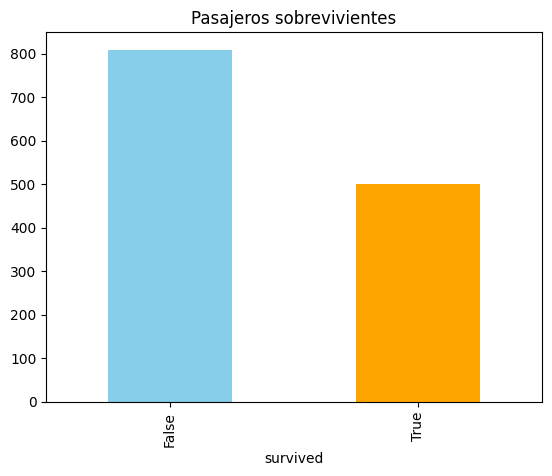

In [15]:
datos_titanic["survived"].value_counts().plot(
    kind="bar", color=["skyblue", "orange"], title="Pasajeros sobrevivientes"
)

### Variables Numéricas

In [16]:
columnas_numericas = list(datos_titanic.select_dtypes(include=["number"]).columns)
columnas_numericas

['age', 'sibsp', 'parch', 'fare']

#### Edad

In [17]:
column = "age"

datos_titanic[column].describe()

count   1046.00
mean      29.88
std       14.41
min        0.17
25%       21.00
50%       28.00
75%       39.00
max       80.00
Name: age, dtype: float64

In [18]:
# ¿Cuántos valores únicos de edad hay?

datos_titanic[column].nunique()

98

<Axes: title={'center': 'age histogram'}, ylabel='Frequency'>

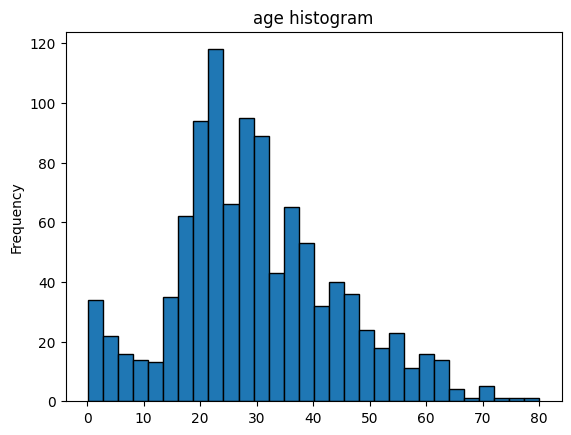

In [19]:
# Histograma con todas las edades

datos_titanic[column].plot(
    kind="hist", bins=30, edgecolor="black", title=f"{column} histogram"
)

ModuleNotFoundError: No module named 'scipy'

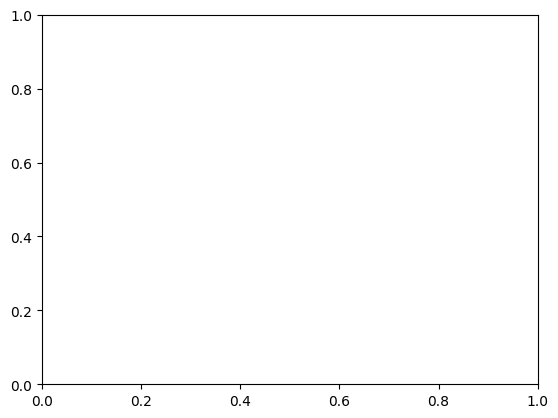

In [20]:
# Gráfico de densidad

datos_titanic[column].plot(
    kind="kde", title=f"{column} distribution"
)

<Axes: title={'center': 'age boxplot'}>

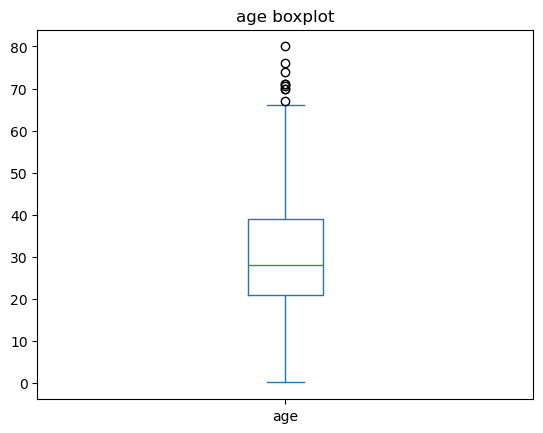

In [ ]:
# Diagrama de caja

datos_titanic[column].plot(kind="box", title=f"{column} boxplot")

#### sibsp: hermanos/cónyugues

In [ ]:
column = "sibsp"

In [ ]:
datos_titanic[column].describe()

count   1309.00
mean       0.50
std        1.04
min        0.00
25%        0.00
50%        0.00
75%        1.00
max        8.00
Name: sibsp, dtype: float64

In [ ]:
datos_titanic[column].nunique()

7

In [ ]:
# Valores únicos
datos_titanic[column].unique()

array([0, 1, 2, 3, 4, 5, 8], dtype=int8)

<Axes: title={'center': 'sibsp histogram'}, ylabel='Frequency'>

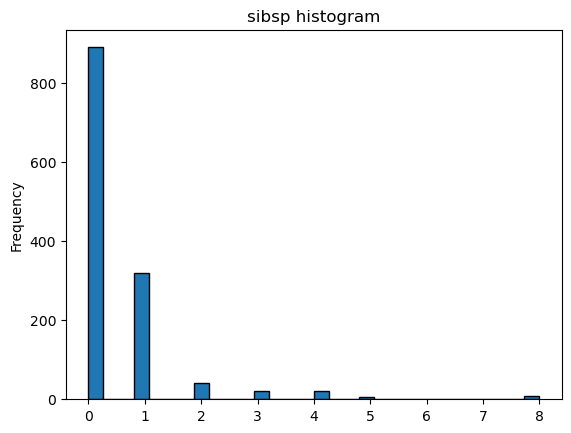

In [ ]:
# Histograma con todas las la cantidad de hermanos, hermanas y cónyuges

datos_titanic[column].plot(
    kind="hist", bins=30, edgecolor="black", title=f"{column} histogram"
)

<Axes: title={'center': 'sibsp boxplot'}>

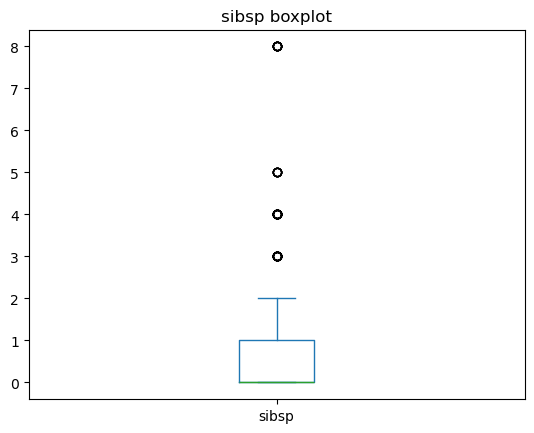

In [ ]:
# Diagrama de caja

datos_titanic[column].plot(kind="box", title=f"{column} boxplot")

#### parch: padres/hijos

In [ ]:
# parents/children. Número de padres y/o hijos que acompañaba el pasajero en el viaje
column = "parch"

In [ ]:
datos_titanic[column].describe()

count   1309.00
mean       0.39
std        0.87
min        0.00
25%        0.00
50%        0.00
75%        0.00
max        9.00
Name: parch, dtype: float64

<Axes: title={'center': 'parch histogram'}, ylabel='Frequency'>

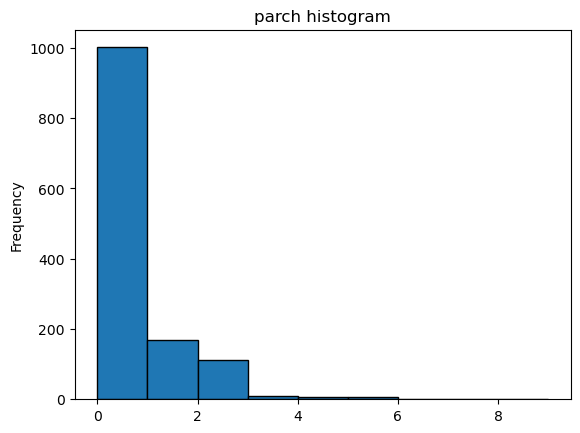

In [ ]:
datos_titanic[column].plot(
    kind="hist", bins=9, edgecolor="black", title=f"{column} histogram"
)

#### fare: tarifa en libras esterlinas

In [ ]:
# Recordar que esta es la tarifa o precio del boleto

column = "fare"
datos_titanic[column].describe()

count   1308.00
mean      33.30
std       51.76
min        0.00
25%        7.90
50%       14.45
75%       31.27
max      512.33
Name: fare, dtype: float64

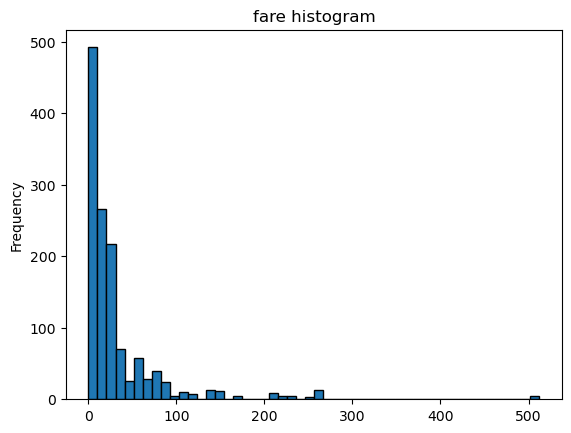

In [ ]:
datos_titanic[column].plot(
    kind="hist", bins=50, edgecolor="black", title=f"{column} histogram"
);

<Axes: title={'center': 'fare boxplot'}>

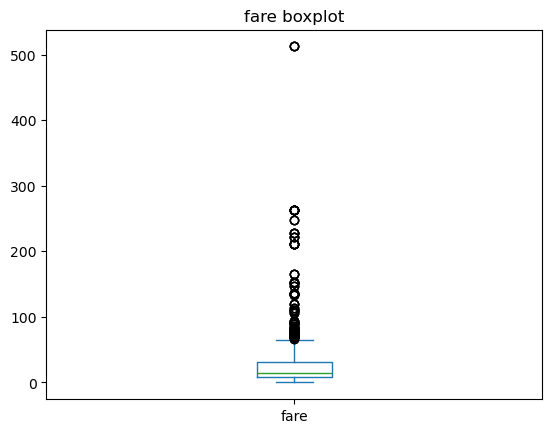

In [ ]:
datos_titanic[column].plot(
    kind="box", title=f"{column} boxplot"
)

### Variables Categóricas

In [ ]:
variables_categoricas = list(datos_titanic.select_dtypes(include=["category"]).columns)
variables_categoricas

['pclass', 'sex', 'embarked']

#### pclass

In [ ]:
column = "pclass"
datos_titanic[column].describe()

count     1309
unique       3
top          3
freq       709
Name: pclass, dtype: int64

In [ ]:
datos_titanic[column].unique()

[1, 2, 3]
Categories (3, int64): [3 < 2 < 1]

In [ ]:
datos_titanic[column].value_counts()

pclass
3    709
1    323
2    277
Name: count, dtype: int64

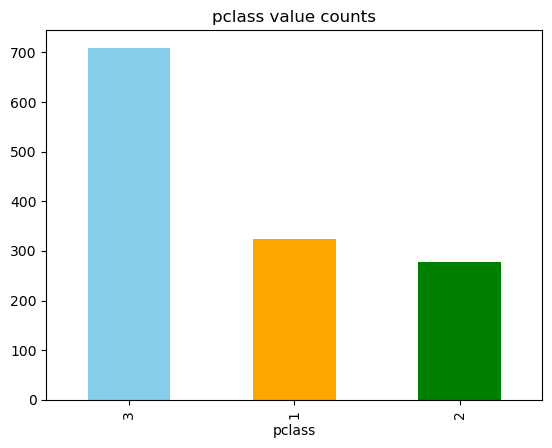

In [ ]:
datos_titanic[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange", "green"], title=f"{column} value counts"
);

#### sex

In [ ]:
column = "sex"
datos_titanic[column].describe()

count     1309
unique       2
top       male
freq       843
Name: sex, dtype: object

In [ ]:
datos_titanic[column].unique()

['female', 'male']
Categories (2, object): ['female', 'male']

In [ ]:
datos_titanic[column].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

<Axes: title={'center': 'sex'}, xlabel='sex'>

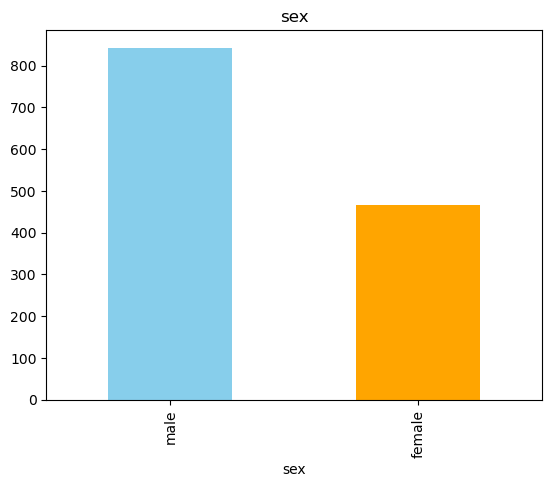

In [ ]:
datos_titanic[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange"], title=f"{column}"
)

#### embarked

Recordar que esta variable hace referencia a los puertos donde embarcaron los pasajeros:
* C: Cherbourg
* Q: Queenstown
* S: Southampton

In [ ]:
column = "embarked"
datos_titanic[column].describe()

count     1307
unique       3
top          S
freq       914
Name: embarked, dtype: object

In [ ]:
datos_titanic[column].unique()

['S', 'C', NaN, 'Q']
Categories (3, object): ['C', 'Q', 'S']

In [ ]:
datos_titanic[column].value_counts()

embarked
S    914
C    270
Q    123
Name: count, dtype: int64

<Axes: title={'center': 'embarked value counts'}, xlabel='embarked'>

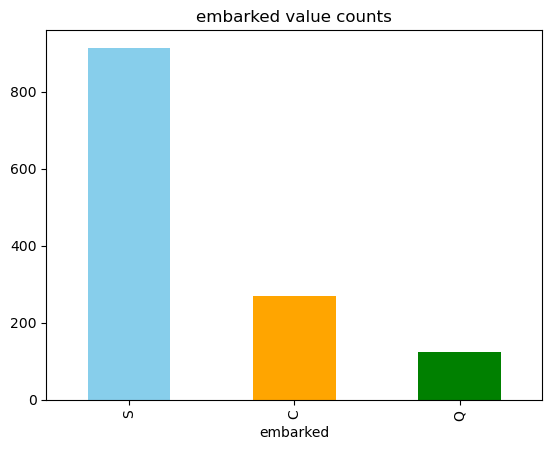

In [ ]:
datos_titanic[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange", "green"], title=f"{column} value counts"
)

### String Columns

In [ ]:
datos_titanic["name"].sample(5)

1044                 Murphy, Miss. Nora
1101       Panula, Master. Eino Viljami
172            Julian, Mr. Henry Forbes
257     Schabert, Mrs. Paul (Emma Mock)
231      Peuchen, Major. Arthur Godfrey
Name: name, dtype: object

In [ ]:
datos_titanic["name"].nunique()

1307

## Análisis Bivariado

En este punto es importante verificar la relación entre la variable objetivo y las otras variables.

La variable objetivo es `survived`

### Variable objetivo vs Variables numéricas

#### Sobreviviente vs Edad (survived vs age)

age    Axes(0.125,0.11;0.775x0.77)
dtype: object

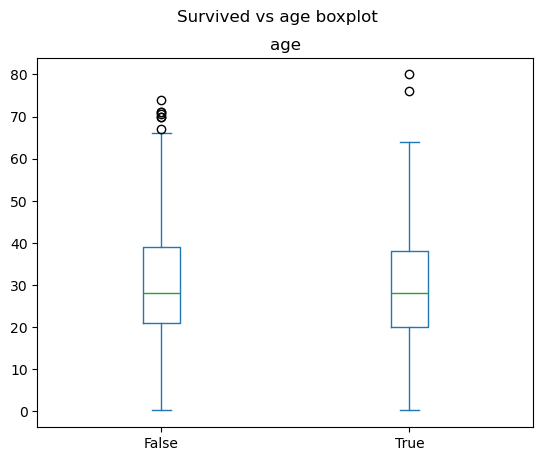

In [ ]:
variable = "age"

datos_titanic.plot(
    kind = "box",
    column=variable,
    by="survived",
    grid=False,
    title=f"Survived vs {variable} boxplot"
)

#### Sobreviviente vs hermanos/cónyuges (survived vs sibsp)

sibsp    Axes(0.125,0.11;0.775x0.77)
dtype: object

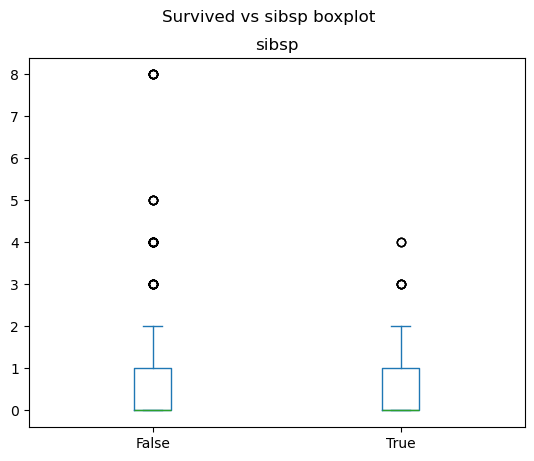

In [ ]:
variable = "sibsp"

datos_titanic.plot(
    kind="box",
    column=variable,
    by="survived",
    grid=False,
    title=f"Survived vs {variable} boxplot"
)

<Axes: title={'center': 'survived vs sibsp diagrama de densidad'}, xlabel='sibsp', ylabel='Density'>

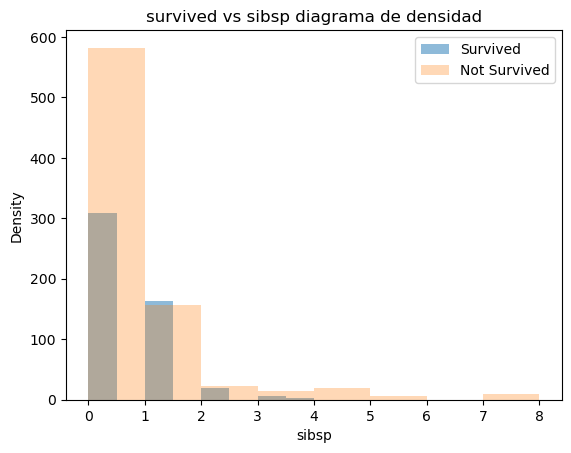

In [ ]:
datos_titanic[datos_titanic["survived"] == 1][variable].plot(
    kind="hist",
    label="Survived",
    legend=True,
    bins=8,
    alpha=0.5,
    title=f"survived vs {variable} diagrama de densidad"
)

datos_titanic[datos_titanic["survived"] == 0][variable].plot(
    kind="hist",
    label="Not Survived",
    legend=True,
    bins=8,
    alpha=0.3,
    xlabel=variable,
    ylabel="Density"
)

#### Sobrevivientes vs Padres/Hijos (survived vs parch)

parch    Axes(0.125,0.11;0.775x0.77)
dtype: object

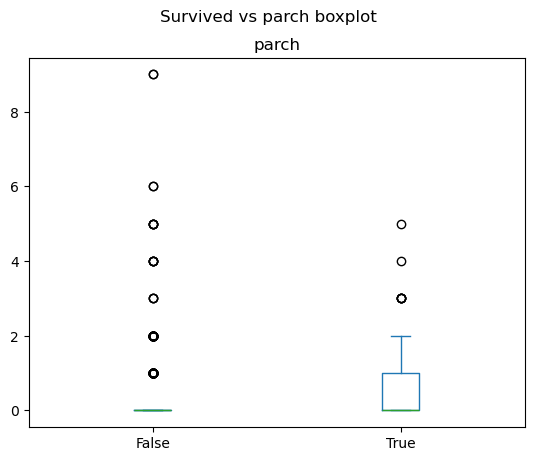

In [ ]:
variable = "parch"

datos_titanic.plot(
    kind="box",
    column=variable,
    by="survived",
    grid=False,
    title=f"Survived vs {variable} boxplot"
)

#### Sobrevivientes vs Tarifa (survived vs fare)

fare    Axes(0.125,0.11;0.775x0.77)
dtype: object

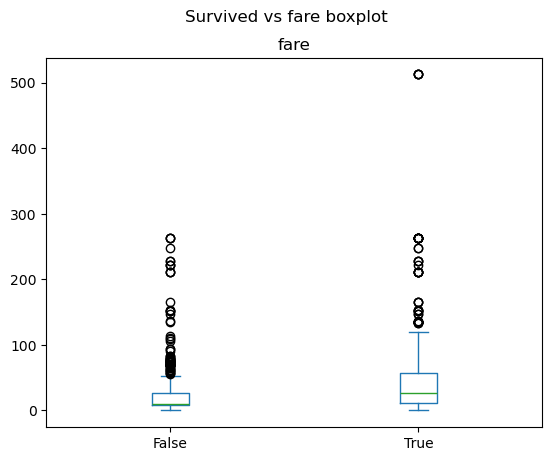

In [ ]:
variable = "fare"

datos_titanic.plot(
    kind="box",
    column=variable,
    by="survived",
    grid=False,
    title=f"Survived vs {variable} boxplot",
)

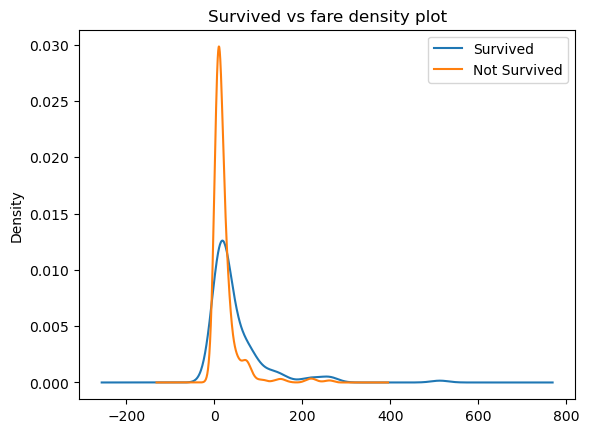

In [ ]:
datos_titanic[datos_titanic["survived"] == 1][variable].plot(
    kind="kde",
    label="Survived",
    legend=True,
    title=f"Survived vs {variable} density plot",
)
datos_titanic[datos_titanic["survived"] == 0][variable].plot(
    kind="kde",
    label="Not Survived",
    legend=True,
    xlabel=variable,
    ylabel="Density",
);

### Variables Objetivo vs Variables Categóricas

Una `crosstrab` es una herramienta estadística que se utiliza para resumir y analizar la relación entre dos variables categóricas. En este caso, se usa para crear una tabla que muestra la frecuencia de las combinaciones de valores entre dos columnas de un DataFrame.

#### survived vs pclass

In [ ]:
column = "pclass"

(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption("Survived vs Pclass")
)

survived,False,True,All
pclass,,,
3,528,181,709
2,158,119,277
1,123,200,323
All,809,500,1309


In [ ]:
# Este script permite agrupar los valores únicos del DataFrame y calcular la media de la columna
# survived para cada grupo.

datos_titanic.groupby(column, observed=True).agg({"survived": "mean"}) * 100

,survived
pclass,
3,25.53
2,42.96
1,61.92


En la tabla anterior se puede ver que los pasajeros de segunda clase en promedio sobrevivieron el doble que los pasajeros de tercera clase. A su vez, la mayor cantidad de sobrevivientes es de primera clase.

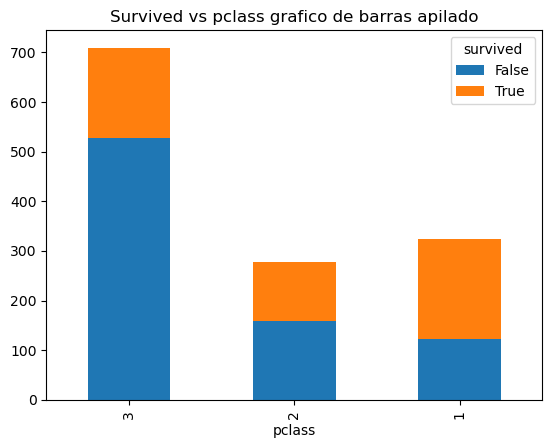

In [ ]:
(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"]).plot(
        kind="bar", stacked=True, title=f"Survived vs {column} grafico de barras apilado"
    )
);

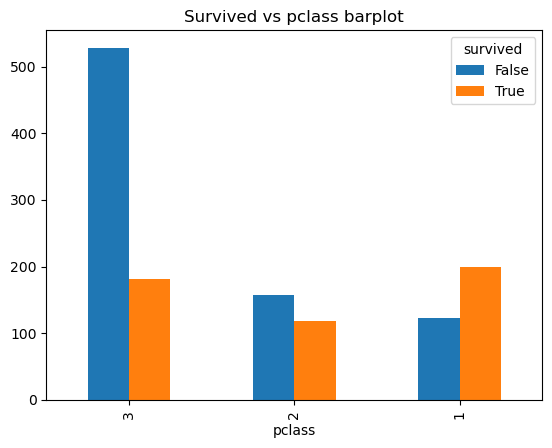

In [ ]:
# Gráfico de barras

(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"]).plot(
        kind="bar",
        title=f"Survived vs {column} barplot",
    )
);


#### survived vs sex

In [ ]:
column = "sex"

(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption("Survived vs pclass Heatmap")
)

survived,False,True,All
sex,,,
female,127,339,466
male,682,161,843
All,809,500,1309


In [ ]:
datos_titanic.groupby(column, observed=True).agg({"survived": "mean"}) * 100

,survived
sex,
female,72.75
male,19.10


<Axes: title={'center': 'Survived vs sex stacked barplot'}, xlabel='sex'>

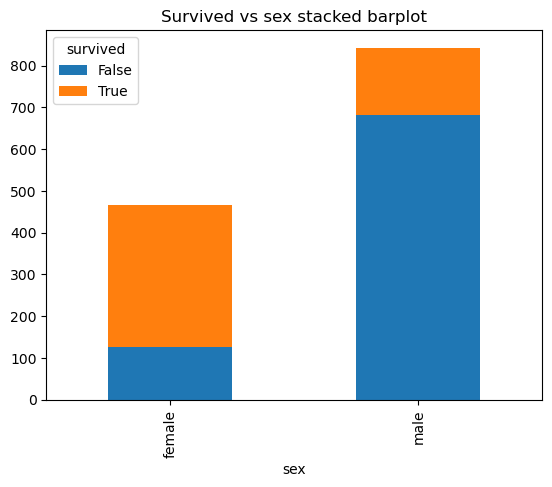

In [ ]:
(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"]).plot(
        kind="bar", stacked=True, title=f"Survived vs {column} stacked barplot"
    )
)

#### survived vs embarked

In [ ]:
column = "embarked"

(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption("Survived vs Embarked Heatmap")
)

survived,False,True,All
embarked,,,
C,120,150,270
Q,79,44,123
S,610,304,914
All,809,498,1307


In [ ]:
datos_titanic.groupby(column, observed=True).agg({"survived": "mean"}) * 100

,survived
embarked,
C,55.56
Q,35.77
S,33.26


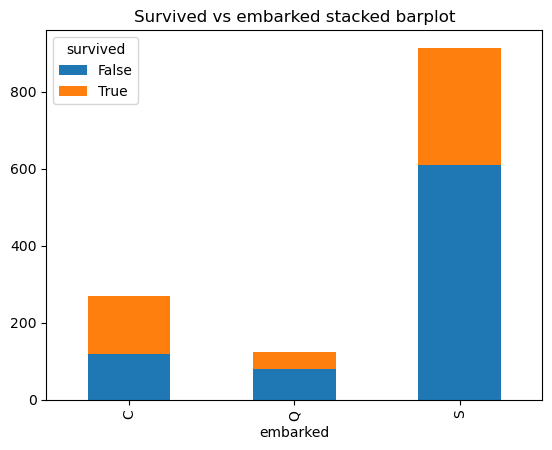

In [ ]:
(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"]).plot(
        kind="bar", stacked=True, title=f"Survived vs {column} stacked barplot"
    )
);


### Variables Numéricas vs Numéricas

#### Edad vs sibsp (age vs sibsp)

<Axes: title={'center': 'Diagrama de dispersión de edad vs sibsp'}, xlabel='age', ylabel='sibsp'>

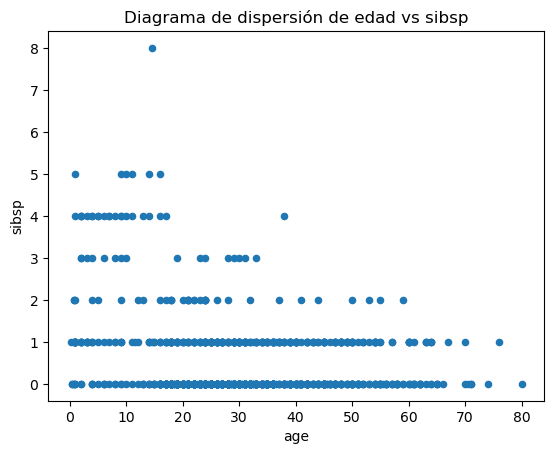

In [ ]:
datos_titanic.plot(
    kind="scatter",
    x="age",
    y="sibsp",
    title="Diagrama de dispersión de edad vs sibsp"
)

#### Edad vs Tarifa (age vs fare)

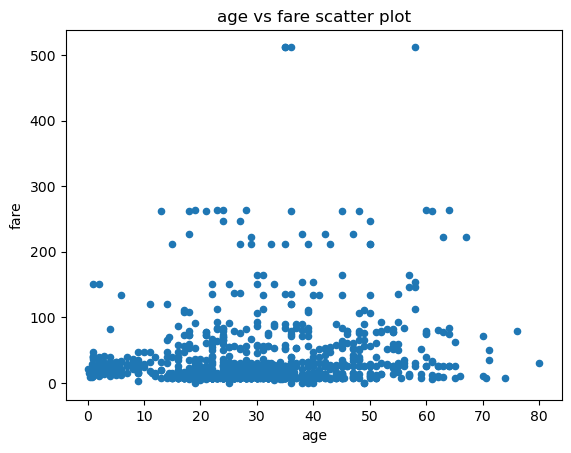

In [ ]:
datos_titanic.plot(
    kind="scatter",
    x="age",
    y="fare",
    title="age vs fare scatter plot",
);


#### sibsp vs parch

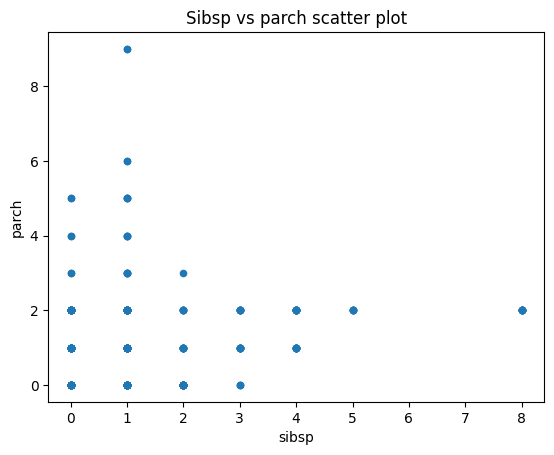

In [22]:
# scatter plot of sibsp vs parch

datos_titanic.plot(
    kind="scatter",
    x="sibsp",
    y="parch",
    title="Sibsp vs parch scatter plot",
);

### Variables Categóricas vs Variables Categóricas

#### pclass vs sex

In [24]:
column_1 = "pclass"
column_2 = "sex"

(
    pd.crosstab(datos_titanic[column_1], datos_titanic[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"Mapa de Calor {column_1} vs {column_2}")
)


sex,female,male,All
pclass,,,
3,216,493,709
2,106,171,277
1,144,179,323
All,466,843,1309


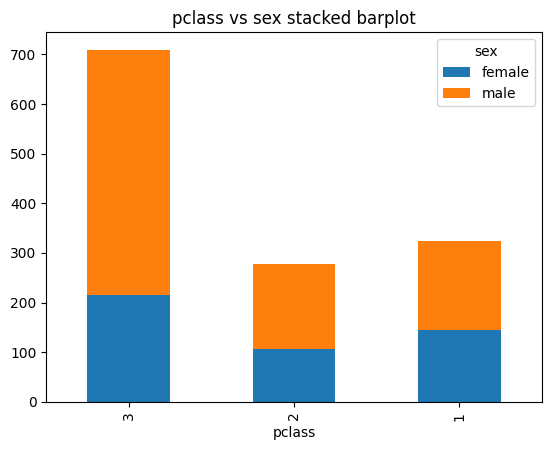

In [25]:
(
    pd.crosstab(datos_titanic[column_1], datos_titanic[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
);


#### sex vs embarked

In [27]:
column_1 = "sex"
column_2 = "embarked"

(
    pd.crosstab(datos_titanic[column_1], datos_titanic[column_2], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption(f"Mapa de Calor {column_1} vs {column_2}")
)


embarked,C,Q,S,All
sex,,,,
female,113,60,291,464
male,157,63,623,843
All,270,123,914,1307


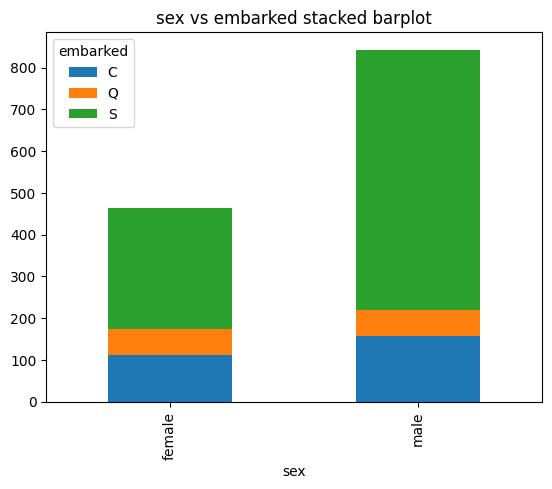

In [28]:
(
    pd.crosstab(datos_titanic[column_1], datos_titanic[column_2]).plot(
        kind="bar", stacked=True, title=f"{column_1} vs {column_2} stacked barplot"
    )
);


### Variables Categóricas vs Numéricas

#### edad vs pclass

/tmp/ipykernel_2392/1452861870.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  datos_titanic.plot(


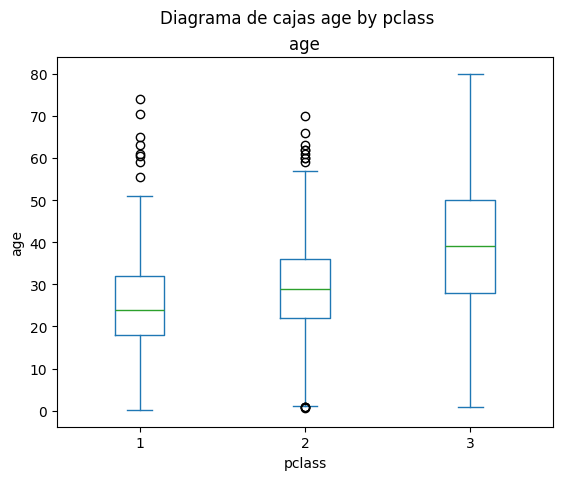

In [30]:
column_cat = "pclass"
column_num = "age"

datos_titanic.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"Diagrama de cajas {column_num} by {column_cat}",
    grid=False,
);


#### sexo vs edad

/tmp/ipykernel_2392/1624996401.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  datos_titanic.plot(


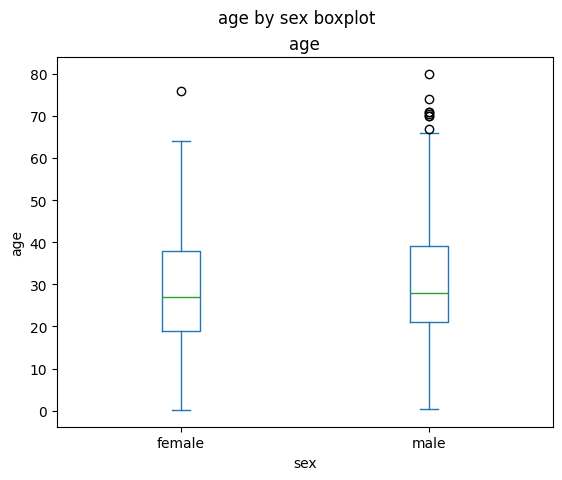

In [31]:
column_cat = "sex"
column_num = "age"

datos_titanic.plot(
    kind="box",
    column=column_num,
    by=column_cat,
    xlabel=column_cat,
    ylabel=column_num,
    title=f"{column_num} by {column_cat} boxplot",
    grid=False,
);


### Análisis Multivariado

Es importante revisar la relación entre la variable objetivo y las múltiples variables.

#### Variable Objetivo vs Edad vs Sexo

<Axes: xlabel='pclass', ylabel='age'>

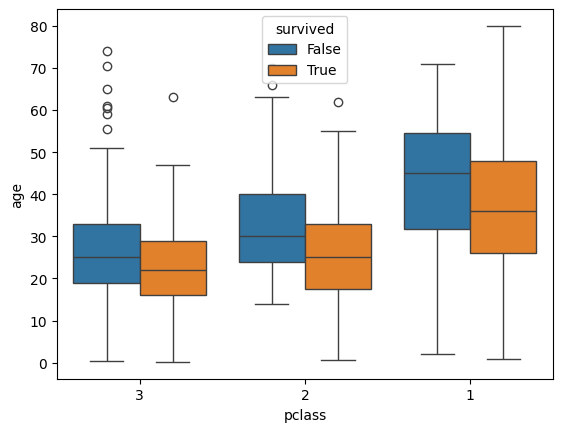

In [32]:
sns.boxplot(data=datos_titanic, x="pclass", y="age", hue="survived")

#### Variable Objetivo vs Edad vs pclass

<Axes: xlabel='pclass', ylabel='age'>

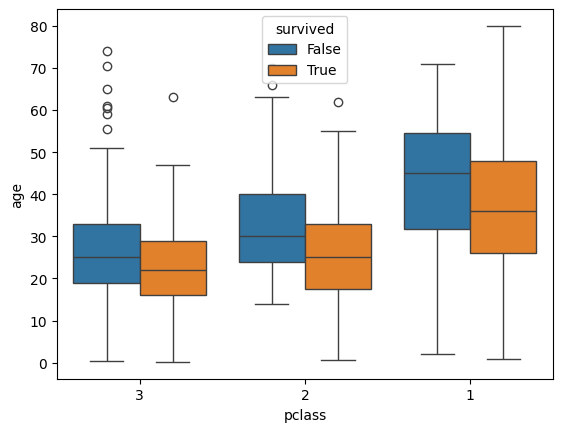

In [33]:
sns.boxplot(data=datos_titanic, x="pclass", y="age", hue="survived")

#### Variable Objetivo vs Sexo vs pclass

In [41]:
(
    datos_titanic[["sex", "pclass", "survived"]]
    .groupby(["pclass", "sex"], observed=True)
    .mean()
    * 100
)

survived
pclass sex             
3      female     49.07
       male       15.21
2      female     88.68
       male       14.62
1      female     96.53
       male       34.08

Casi el 100% de la `pclass` 1 equivale a mujeres que sobrevivieron y también para la clase 2. Por su parte, en la clase 3, solo sobrevivió alrededor del 50% de las mujeres. Por su parte, casi todos los hombres de la clase 3 no sobrevivieron.

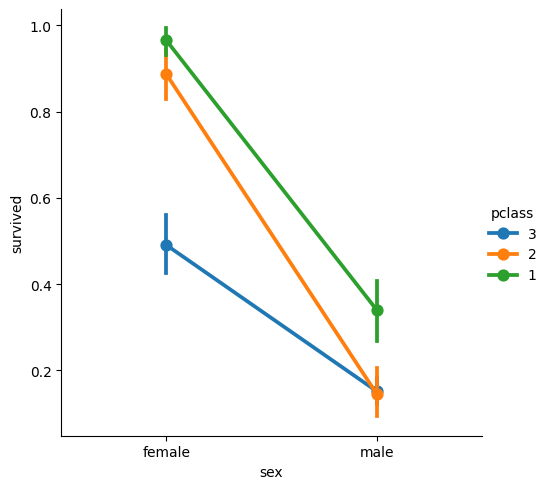

In [42]:
sns.catplot(data=datos_titanic, x="sex", y="survived", hue="pclass", kind="point")

En el siguiente ejemplo, el gráfico es útil para visualizar cómo la clase y el género influyeron en la tasa de supervivencia.

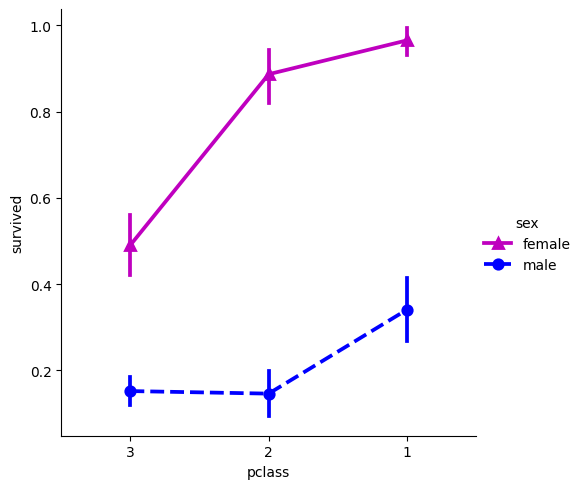

In [44]:
sns.catplot(
    data=datos_titanic,
    x="pclass",
    y="survived",
    hue="sex",
    palette={"male": "b", "female": "m"}, # hombres con color azul, mujeres con color rojo
    markers=["^", "o"], # marcadores para representar puntos en el gráfico
    linestyles=["-", "--"], # Estilos de línea para conectar puntos
    kind="point"
)

### Análisis de todas las variables numéricas

In [45]:
columnas_numericas

['age', 'sibsp', 'parch', 'fare']

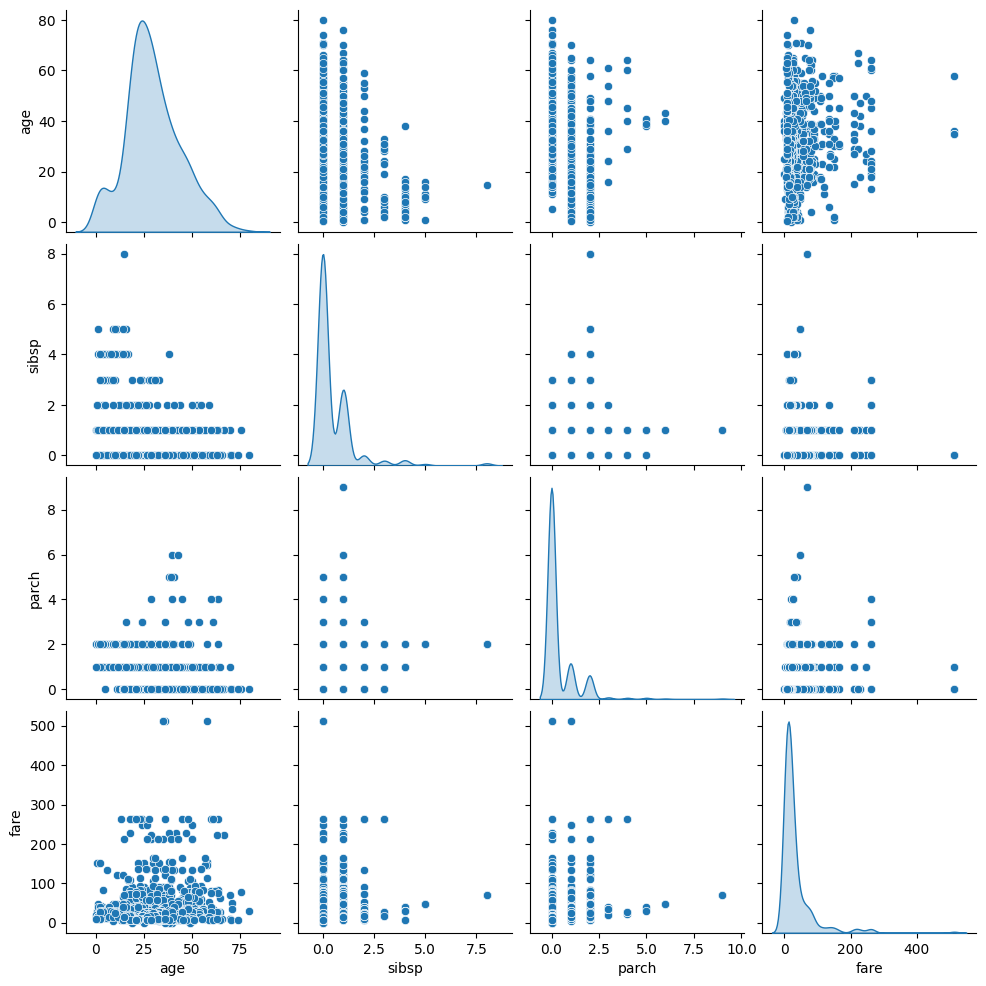

In [46]:
sns.pairplot(datos_titanic[columnas_numericas], diag_kind="kde");

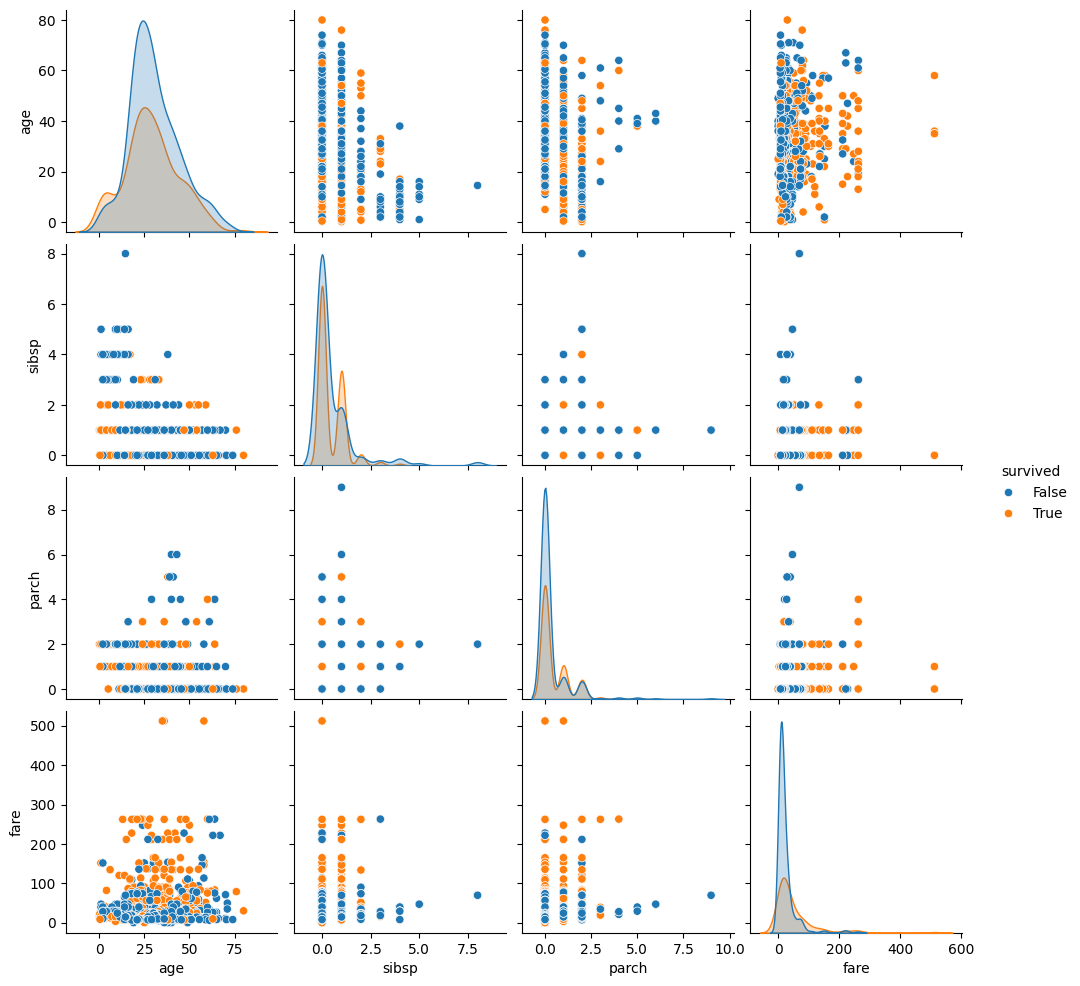

In [ ]:
df = datos_titanic[[*columnas_numericas, "survived"]]

sns.pairplot(df, hue="survived", diag_kind="kde")

# Análisis de resultados y conclusiones

* Casi todas las mujeres de la clase 1 (Pclass 1) sobrevivieron, al igual que la mayoría de las mujeres de la clase 2 (Pclass 2). La tasa de supervivencia de las mujeres de la clase 3 (Pclass 3) es del 50%, y casi todos los hombres de la clase 3 (86%) lamentablemente no sobrevivieron.

* La edad no está correlacionada con la tarifa.

* La tasa de supervivencia entre los pasajeros de primera clase es más alta.

* La tasa de supervivencia de los pasajeros que embarcaron en Cherboug es más alta que la de los demás.

# Otras alternativas para hacer una inspección rápida de los datos

In [6]:
import sweetviz as sv

/home/dpalacioj/miniconda3/envs/titanic/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import sweetviz as sv

# Genera el reporte con Sweetviz, especificando 'survived' como variable objetivo

reporte_sweetviz = sv.analyze(datos_titanic, target_feat='survived')

# Obtener la ruta del notebook actual
ruta_EDA_sweetviz = Path.cwd().resolve().parent / "analisis_sweetviz"

ruta_archivo = ruta_EDA_sweetviz / "EDA_sweetviz_titanic.html"

# Crear directorio si no existe
ruta_EDA_sweetviz.mkdir(parents=True, exist_ok=True)

reporte_sweetviz.show_html(ruta_archivo)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report /mnt/d/DataAI-Fundamentos-Aplicaciones/Analitica/proyectos/titanic/analisis_sweetviz/EDA_sweetviz_titanic.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Try running the update-desktop-database command. If you
don't have this command you should install the
desktop-file-utils package. This package is available from
http://freedesktop.org/wiki/Software/desktop-file-utils/
No applications found for mimetype: text/html
./usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method avai